<a href="https://colab.research.google.com/github/sonixx00/Starshun/blob/main/lb3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install simpy

--- Моделювання ЛР №3 розпочато ---

Результати для Варіанту 20 (лямбда=4.0):
Обслуговано: 167
Відмов за часом: 179
Сер. час очікування: 12.93


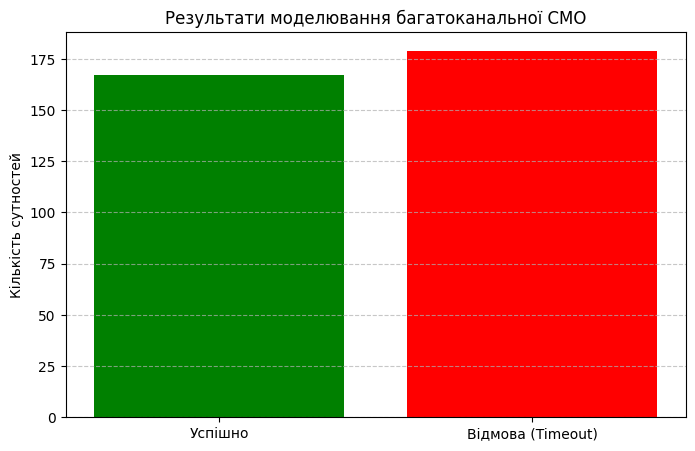

In [ ]:
import simpy
import random
import numpy as np
import matplotlib.pyplot as plt

# --- Константи та параметри системи ---
LAMBDA_NEW = 4.0        # Інтенсивність вхідного потоку
NUM_SERVERS = 15        # Кількість каналів (серверів)
MAX_WAIT_TIME = 15      # Максимальний час очікування в черзі
SIM_TIME = 100          # Загальний час моделювання

ENTITY_TYPES = ['Fast', 'Standard']
PROBS = [0.3, 0.7]      # Ймовірність появи кожного типу
SERVICE_TIMES = {'Fast': 5, 'Standard': 12}

# Глобальна статистика
stats = {
    'served': 0,
    'timed_out': 0,
    'wait_times': []
}

# --- Процеси моделювання ---

def customer(env, name, servers, ent_type):
    """Процес поведінки клієнта"""
    arrival_time = env.now

    # Визначаємо тривалість обслуговування (експоненціальний розподіл)
    serv_duration = random.expovariate(1.0 / SERVICE_TIMES[ent_type])

    with servers.request() as request:
        # Клієнт чекає звільнення сервера або закінчення терміну терпіння
        results = yield request | env.timeout(MAX_WAIT_TIME)

        wait = env.now - arrival_time
        stats['wait_times'].append(wait)

        if request in results:
            # Випадок 1: Сервер звільнився раніше, ніж вийшов час очікування
            stats['served'] += 1
            yield env.timeout(serv_duration)
        else:
            # Випадок 2: Час очікування вичерпано (відмова)
            stats['timed_out'] += 1

def source(env, servers):
    """Генератор вхідного потоку клієнтів"""
    i = 0
    while True:
        # Час до появи наступного клієнта
        yield env.timeout(random.expovariate(LAMBDA_NEW))
        i += 1
        # Випадковий вибір типу клієнта
        etype = random.choices(ENTITY_TYPES, weights=PROBS)[0]
        env.process(customer(env, f'Клієнт_{i}', servers, etype))

# --- Запуск моделювання ---

print("--- Моделювання ЛР №3 розпочато ---")

env = simpy.Environment()
servers = simpy.Resource(env, capacity=NUM_SERVERS)

# Реєструємо джерело заявок у середовищі
env.process(source(env, servers))

# Запускаємо симуляцію
env.run(until=SIM_TIME)

# --- Виведення результатів ---

print(f"\nРезультати для Варіанту 20 (лямбда={LAMBDA_NEW}):")
print(f"Обслуговано: {stats['served']}")
print(f"Відмов за часом: {stats['timed_out']}")

if stats['wait_times']:
    avg_wait = np.mean(stats['wait_times'])
    print(f"Сер. час очікування: {avg_wait:.2f}")

# --- Візуалізація ---

plt.figure(figsize=(8, 5))
labels = ['Успішно', 'Відмова (Timeout)']
values = [stats['served'], stats['timed_out']]

plt.bar(labels, values, color=['green', 'red'])
plt.title("Результати моделювання багатоканальної СМО")
plt.ylabel("Кількість сутностей")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()